# Project 1 — Retail Price Intelligence: EDA

**Dataset:** 999 books scraped from books.toscrape.com across 50 categories  
**Question:** Do star ratings correlate with book prices?  
**Tools:** pandas, scipy, matplotlib, seaborn, DuckDB

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
%matplotlib inline
sns.set_theme(style='whitegrid')
print('Libraries loaded OK')

Libraries loaded OK


## Load and inspect the cleaned dataset

Data was scraped with `scripts/scraper.py`, then cleaned with `scripts/clean.py`.  
Cleaning steps: 1 duplicate title removed, ratings converted from words to integers 1–5, price bucket added.

In [3]:
df = pd.read_csv(Path('data/cleaned/books_clean.csv'))

print(f'Shape: {df.shape}')  # expect (999, 5)
print(f'Columns: {df.columns.tolist()}')
print(f'\nDtypes:')
print(df.dtypes)
df.head()

Shape: (999, 5)
Columns: ['title', 'category', 'rating_num', 'price_gbp', 'price_bucket']

Dtypes:
title               str
category            str
rating_num        int64
price_gbp       float64
price_bucket        str
dtype: object


,title,category,rating_num,price_gbp,price_bucket
0,It's Only the Himalayas,Travel,2,45.17,high
1,Full Moon over Noahâs Ark: An Odyssey to Mou...,Travel,4,49.43,high
2,See America: A Celebration of Our National Par...,Travel,3,48.87,high
3,Vagabonding: An Uncommon Guide to the Art of L...,Travel,2,36.94,high
4,Under the Tuscan Sun,Travel,3,37.33,high


In [4]:
print('Summary statistics:')
print(df[['rating_num', 'price_gbp']].describe().round(2))
print(f'\nRating distribution:')
print(df['rating_num'].value_counts().sort_index())
print(f'\nPrice bucket distribution:')
print(df['price_bucket'].value_counts())
print(f'\nCategories: {df["category"].nunique()}')

Summary statistics:
       rating_num  price_gbp
count      999.00     999.00
mean         2.92      35.07
std          1.43      14.45
min          1.00      10.00
25%          2.00      22.10
50%          3.00      36.00
75%          4.00      47.47
max          5.00      59.99

Rating distribution:
rating_num
1    226
2    196
3    203
4    179
5    195
Name: count, dtype: int64

Price bucket distribution:
price_bucket
high    516
mid     287
low     196
Name: count, dtype: int64

Categories: 50


## Chart 1: Price Distribution

This histogram shows how book prices are distributed across the 999-book dataset.  
The KDE line smooths the distribution shape. Prices are uniformly spread from £10 to £60 with no sharp spike at any single price point — typical of a synthetic pricing scheme on this sandbox site. In a real retail dataset you'd expect clustering around common price points.

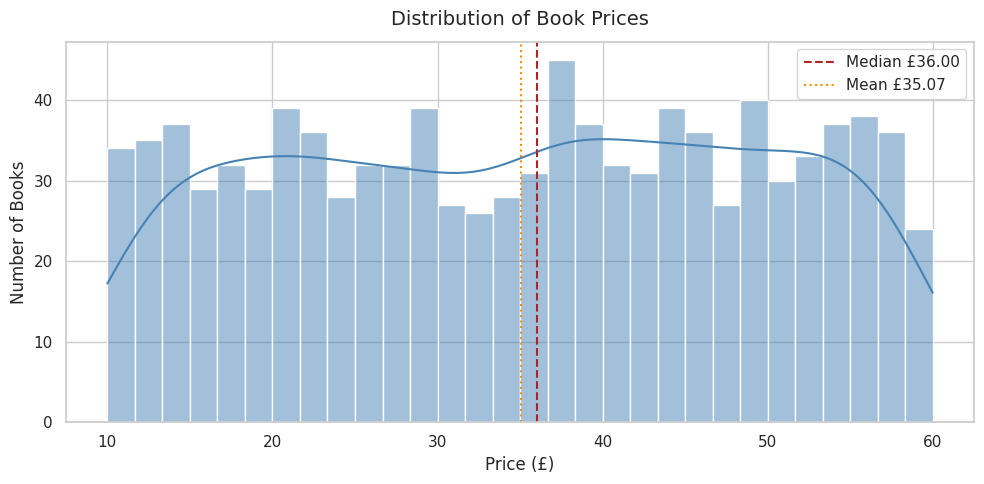

Chart saved to output/charts/price_histogram.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df, x='price_gbp', bins=30, kde=True, color='steelblue', ax=ax)
ax.set_title('Distribution of Book Prices', fontsize=14, pad=12)
ax.set_xlabel('Price (£)', fontsize=12)
ax.set_ylabel('Number of Books', fontsize=12)
ax.axvline(df['price_gbp'].median(), color='firebrick', linestyle='--', label=f'Median £{df["price_gbp"].median():.2f}')
ax.axvline(df['price_gbp'].mean(), color='darkorange', linestyle=':', label=f'Mean £{df["price_gbp"].mean():.2f}')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('output/charts/price_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to output/charts/price_histogram.png')

## Chart 2: Price Spread by Rating

Box plots per rating group with individual data points overlaid.  
Each box shows the interquartile range; the centre line is the median.  
If ratings drove price, we'd see the boxes stair-stepping upward from 1-star to 5-star.  
They don't — all five groups overlap almost entirely, suggesting rating has no pricing signal.

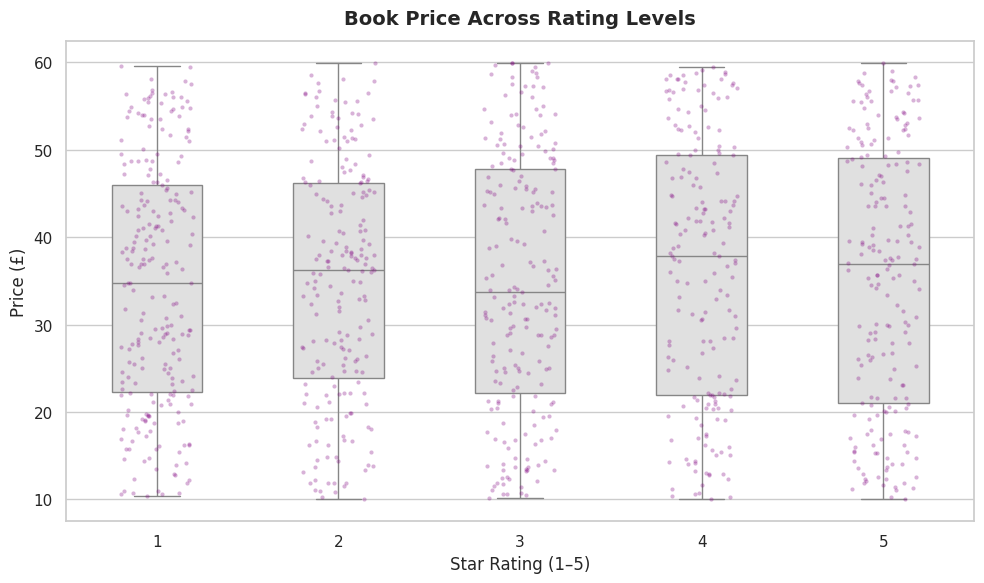

Chart saved to output/charts/rating_vs_price_scatter.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=df, x='rating_num', y='price_gbp',
    color='#e0e0e0', width=0.5, showfliers=False, ax=ax
)
sns.stripplot(
    data=df, x='rating_num', y='price_gbp',
    color='purple', alpha=0.3, jitter=0.2, size=3, ax=ax
)
ax.set_title('Book Price Across Rating Levels', fontsize=14, pad=12, fontweight='bold')
ax.set_xlabel('Star Rating (1–5)', fontsize=12)
ax.set_ylabel('Price (£)', fontsize=12)
plt.tight_layout()
plt.savefig('output/charts/rating_vs_price_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to output/charts/rating_vs_price_scatter.png')

## Chart 3: Price Distribution by Category

Each row is a category, sorted by median price (highest at top).  
This is where price differences actually live. Suspense, Novels, and Politics charge £45–58 at the median; Crime and Academic sit at £11–13.  
The spread between the cheapest and most expensive category is far larger than any spread between rating groups — confirming that genre, not rating, drives price.

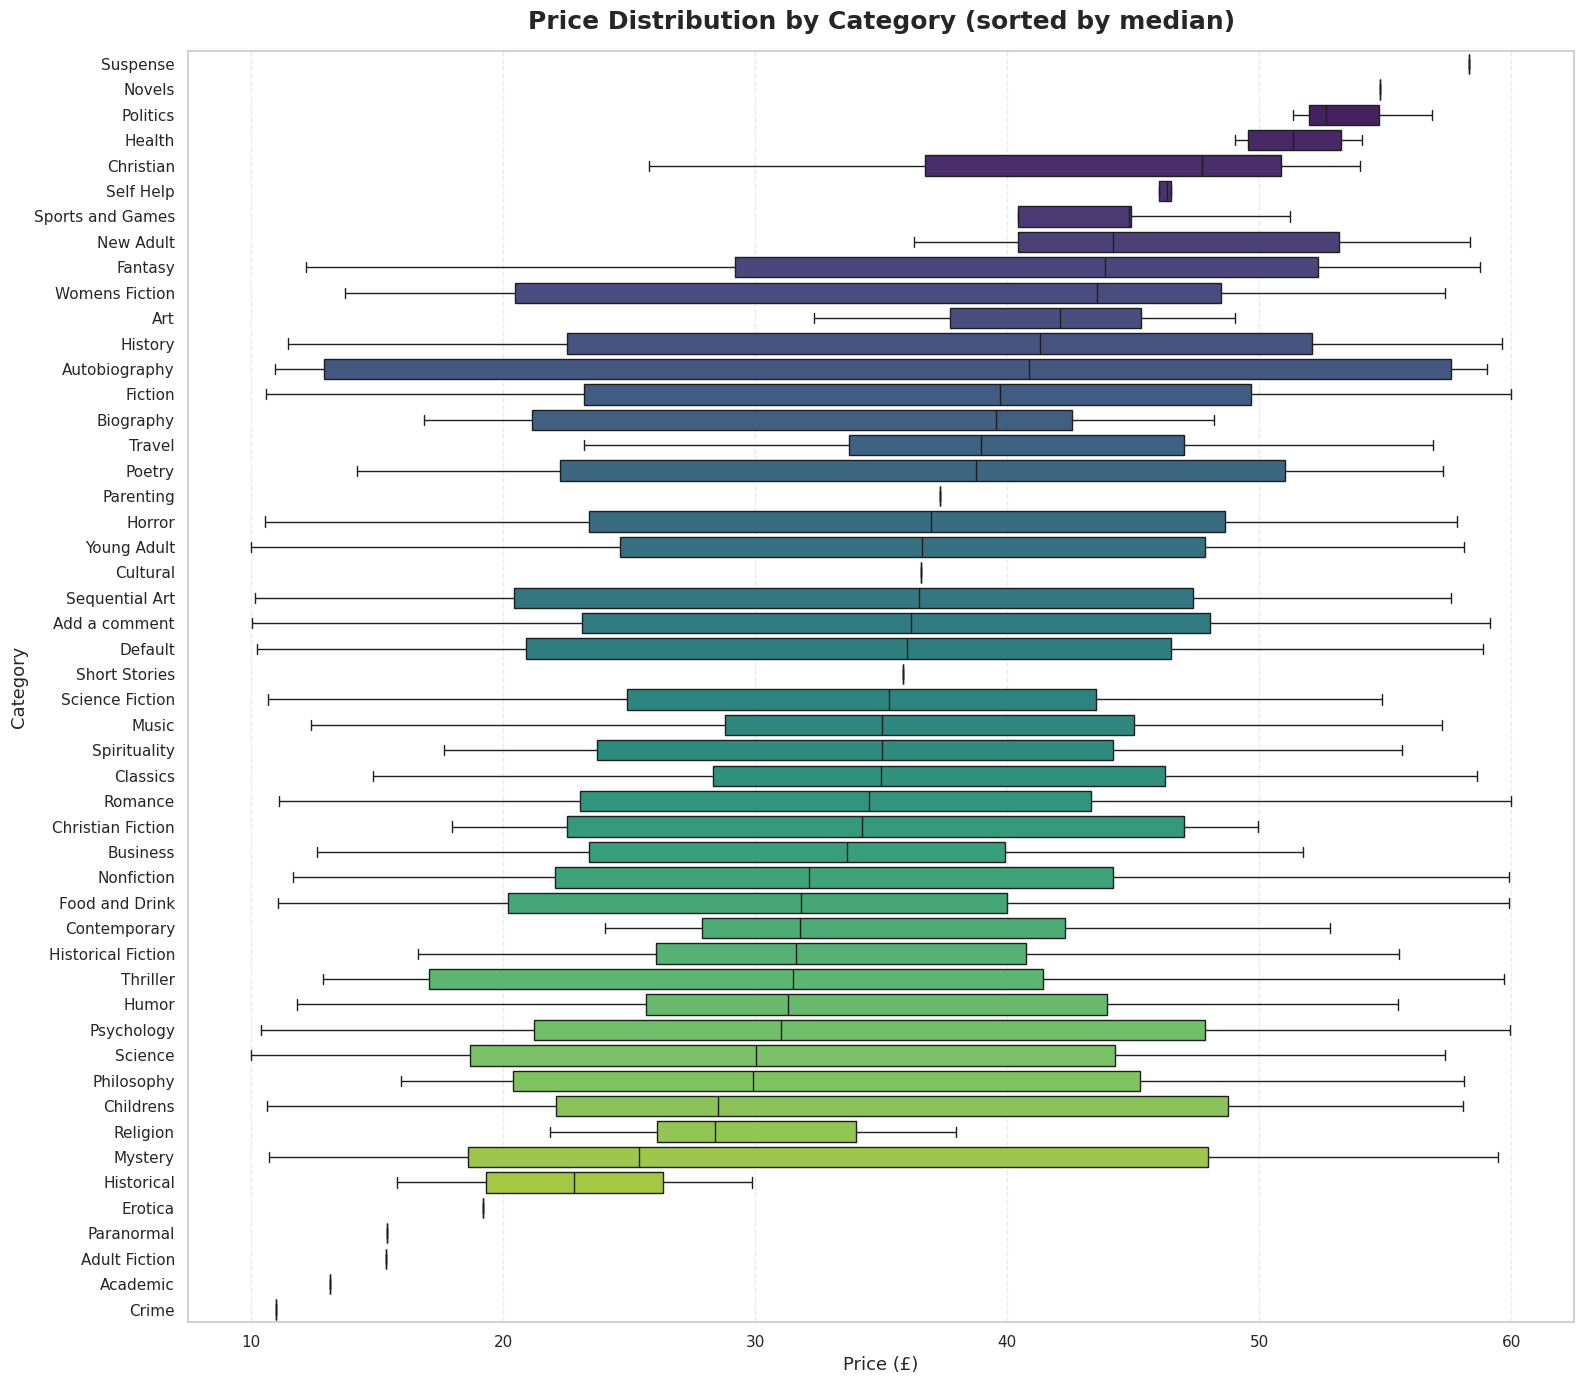

Chart saved to output/charts/category_boxplot.png


In [7]:
category_order = (
    df.groupby('category')['price_gbp']
    .median()
    .sort_values(ascending=False)
    .index
)
fig, ax = plt.subplots(figsize=(16, 14))
sns.boxplot(
    data=df, x='price_gbp', y='category',
    order=category_order, palette='viridis',
    linewidth=1.0, showfliers=False, ax=ax
)
ax.set_title('Price Distribution by Category (sorted by median)', fontsize=18, fontweight='bold', pad=16)
ax.set_xlabel('Price (£)', fontsize=13)
ax.set_ylabel('Category', fontsize=13)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('output/charts/category_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to output/charts/category_boxplot.png')

## Statistical Tests

Two tests were run to check whether the visual impression holds statistically:
- **Spearman rank correlation** — tests whether higher ratings tend to come with higher prices
- **Kruskal-Wallis test** — non-parametric test for whether price distributions differ across all five rating groups

In [8]:
rho, p_spearman = stats.spearmanr(df['rating_num'], df['price_gbp'])
groups = [g['price_gbp'].values for _, g in df.groupby('rating_num')]
h_stat, p_kruskal = stats.kruskal(*groups)

print('=== Statistical Results ===')
print(f'Spearman rho  : {rho:.4f}')
print(f'Spearman p    : {p_spearman:.4f}  --> {"significant" if p_spearman < 0.05 else "not significant"}')
print(f'Kruskal-Wallis H: {h_stat:.4f}')
print(f'Kruskal-Wallis p: {p_kruskal:.4f}  --> {"significant" if p_kruskal < 0.05 else "not significant"}')
print()
print('Interpretation: No statistically significant relationship between rating and price.')

=== Statistical Results ===
Spearman rho  : 0.0296
Spearman p    : 0.3505  --> not significant
Kruskal-Wallis H: 1.5736
Kruskal-Wallis p: 0.8135  --> not significant

Interpretation: No statistically significant relationship between rating and price.


## Business Insights

1. **Prices are spread fairly evenly** from £10 to £60 with no single price cluster — on a real marketplace this would suggest either a diverse catalogue or synthetic/placeholder pricing.
2. **Star ratings have no pricing signal** (ρ = 0.03, p = 0.35). Customers on this platform cannot use price as a proxy for quality, and sellers are not pricing based on review performance.
3. **Genre is the dominant price driver.** A Suspense book costs nearly 5× a Crime book at the median, regardless of its rating. Category membership predicts price far better than any quality signal.
4. **Most books (52%) fall in the high price bucket** (>£35), with only 20% in the low tier (<£20). The distribution skews toward more expensive titles.
5. **Limitations to keep in mind:** books.toscrape.com uses synthetic prices. These patterns may not generalise to real retail pricing data.

## Challenges Faced

- Ratings were stored as English words ("One", "Two", ...) rather than numbers — had to map them explicitly and add validation to catch any unmapped values.
- One title appeared twice in the same category (Fantasy), which required a deduplication step and a decision about which occurrence to keep.
- Notebook paths broke when run from a different working directory — fixed by using relative `Path()` objects and documenting that notebooks must be run from the project root.
- The sandbox site prices (£10–£60 range, no clusters) look different from real-world price distributions, which limits how generalisable the analysis is.
- Had to choose between Pearson and Spearman correlation — went with Spearman because price distributions are not normal and the relationship with ratings was unlikely to be linear.

## Future Work

- Apply the same pipeline to a real product feed (e.g. Amazon via a public API or Open Library data) to see if category still dominates over rating when prices are real.
- Add a time dimension — scrape the same books on multiple days to track price drift.
- Build an interactive dashboard (Streamlit or Dash) so a reviewer can filter by category and explore pricing interactively.
- Add a simple regression model to quantify how much variance in price is explained by category alone vs. category + rating.